# SIG Sampling Quality
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/17_sig_sampling_quality.ipynb)

`SIG` is the **generative** orientation of sliced iterative
Gaussianization: fit a flow on data, then draw
$\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and push it through the
inverse transform to generate new samples. Its default stopping signal is
the **sliced Wasserstein distance** (SWD), which tracks sample quality
directly.

This notebook fits SIG on 2D and moderate-dimensional targets, generates
samples via `sample()` / `inverse_transform(z)`, compares them to true
samples **visually** (scatter, marginals) and **quantitatively**
(maximum mean discrepancy, sliced Wasserstein distance, per-dimension
Kolmogorov–Smirnov tests).

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.spatial.distance import cdist

from rbig import SIG
from rbig._src.stiefel import wasserstein_1d

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sample-Quality Metrics

- **MMD** (maximum mean discrepancy) with an RBF kernel and the median
  heuristic bandwidth: 0 iff the two distributions match (in the RKHS
  sense). We report the *unbiased* estimate, so values can dip slightly
  below zero for matching distributions.
- **SWD**: mean 1-Wasserstein distance over random 1D projections — the
  same quantity SIG's stopping criterion monitors.

Both are compared against a **noise floor**: the metric between two
independent sets of *true* samples, which is the best any generator could
achieve at this sample size.

In [3]:
def mmd_rbf(X: np.ndarray, Y: np.ndarray, seed: int = 0) -> float:
    """Unbiased MMD^2 with RBF kernel (median-heuristic bandwidth)."""
    D_xy = cdist(X, Y, "sqeuclidean")  # (n, m)
    D_xx = cdist(X, X, "sqeuclidean")  # (n, n)
    D_yy = cdist(Y, Y, "sqeuclidean")  # (m, m)
    # Median heuristic on the pooled pairwise distances.
    gamma = 1.0 / np.median(np.concatenate([D_xy.ravel(), D_xx.ravel()]))
    K_xy = np.exp(-gamma * D_xy)
    K_xx = np.exp(-gamma * D_xx)
    K_yy = np.exp(-gamma * D_yy)
    n, m = X.shape[0], Y.shape[0]
    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)
    return float(
        K_xx.sum() / (n * (n - 1)) + K_yy.sum() / (m * (m - 1)) - 2.0 * K_xy.mean()
    )


def swd(X: np.ndarray, Y: np.ndarray, n_projections: int = 100, seed: int = 0) -> float:
    """Sliced 1-Wasserstein distance over random projections."""
    rng = np.random.default_rng(seed)
    dirs = rng.standard_normal((X.shape[1], n_projections))
    dirs /= np.linalg.norm(dirs, axis=0, keepdims=True)
    P, Q = X @ dirs, Y @ dirs  # (n, n_projections)
    return float(
        np.mean([wasserstein_1d(P[:, j], Q[:, j]) for j in range(n_projections)])
    )

## 2D Targets

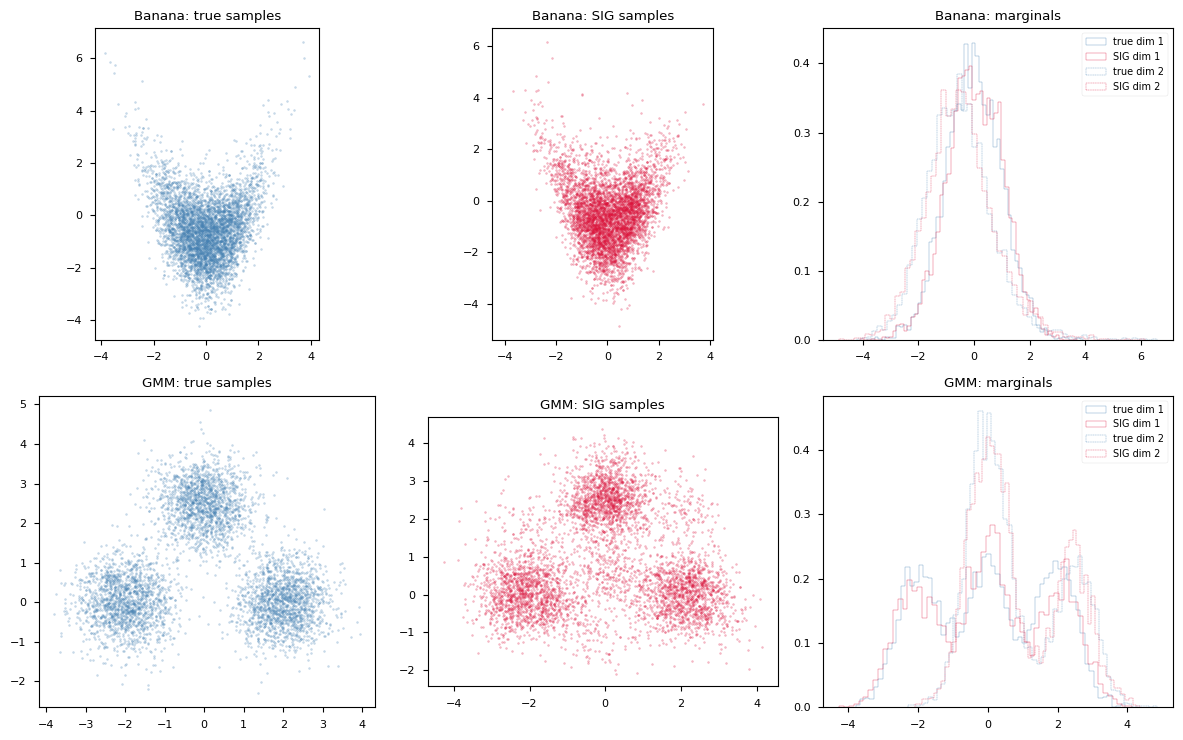

In [4]:
def make_banana(n_samples: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = rng.standard_normal((n_samples, 2))
    return np.stack([x[:, 0], x[:, 1] + 0.5 * x[:, 0] ** 2 - 1.0], axis=1)


def make_gmm(n_samples: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    means = np.array([[-2.0, 0.0], [2.0, 0.0], [0.0, 2.5]])
    labels = rng.integers(0, len(means), size=n_samples)
    return means[labels] + 0.6 * rng.standard_normal((n_samples, 2))


n = 5_000
targets_2d = {
    "Banana": make_banana,
    "GMM": make_gmm,
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
metrics_2d = {}
for row, (name, sampler) in enumerate(targets_2d.items()):
    X_train = sampler(n, seed=0)
    X_true = sampler(n, seed=1)  # fresh true samples, unseen by the model

    model = SIG(n_layers=100, random_state=0).fit(X_train)
    X_gen = model.sample(n, random_state=2)

    metrics_2d[name] = {
        "layers": model.n_layers_,
        "mmd_gen": mmd_rbf(X_gen, X_true),
        "mmd_floor": mmd_rbf(sampler(n, seed=3), X_true),
        "swd_gen": swd(X_gen, X_true),
        "swd_floor": swd(sampler(n, seed=3), X_true),
    }

    for col, (X, title, color) in enumerate(
        [
            (X_true, f"{name}: true samples", "steelblue"),
            (X_gen, f"{name}: SIG samples", "crimson"),
        ]
    ):
        ax = axes[row, col]
        ax.scatter(X[:, 0], X[:, 1], s=2, alpha=0.3, color=color)
        ax.set_title(title)
        ax.set_aspect("equal")

    ax = axes[row, 2]
    for j, ls in [(0, "-"), (1, "--")]:
        ax.hist(
            X_true[:, j], bins=60, density=True, histtype="step",
            color="steelblue", ls=ls, label=f"true dim {j + 1}",
        )
        ax.hist(
            X_gen[:, j], bins=60, density=True, histtype="step",
            color="crimson", ls=ls, label=f"SIG dim {j + 1}",
        )
    ax.set_title(f"{name}: marginals")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [5]:
print(f"{'target':8s} {'layers':>6s} {'MMD² gen':>10s} {'MMD² floor':>11s} {'SWD gen':>9s} {'SWD floor':>10s}")
for name, m in metrics_2d.items():
    print(
        f"{name:8s} {m['layers']:6d} {m['mmd_gen']:10.5f} {m['mmd_floor']:11.5f} "
        f"{m['swd_gen']:9.4f} {m['swd_floor']:10.4f}"
    )

target   layers   MMD² gen  MMD² floor   SWD gen  SWD floor
Banana       14    0.00057    -0.00007    0.0488     0.0238
GMM           6    0.00040     0.00008    0.0743     0.0400


The generated clouds are visually indistinguishable from true draws, and
the MMD/SWD of *generated vs true* sits at (or within a small factor of)
the *true vs true* noise floor.

## Moderate Dimension: 8D Rotated Skew

Independent Gamma(2) sources mixed by a fixed random rotation — every 1D
projection is skewed, so a Gaussian would be a poor generator.

In [6]:
def make_rotated_skew(n_samples: int, seed: int = 0, d: int = 8) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sources = rng.gamma(shape=2.0, scale=1.0, size=(n_samples, d))
    rotation = stats.ortho_group.rvs(d, random_state=123)  # fixed mixing
    return sources @ rotation.T


X8_train = make_rotated_skew(4_000, seed=0)
X8_true = make_rotated_skew(4_000, seed=1)

model8 = SIG(n_layers=100, random_state=0).fit(X8_train)
X8_gen = model8.sample(4_000, random_state=2)
print(f"8D: {model8.n_layers_} layers kept")

8D: 11 layers kept


Per-dimension marginals and pairwise scatter for the first three
dimensions:

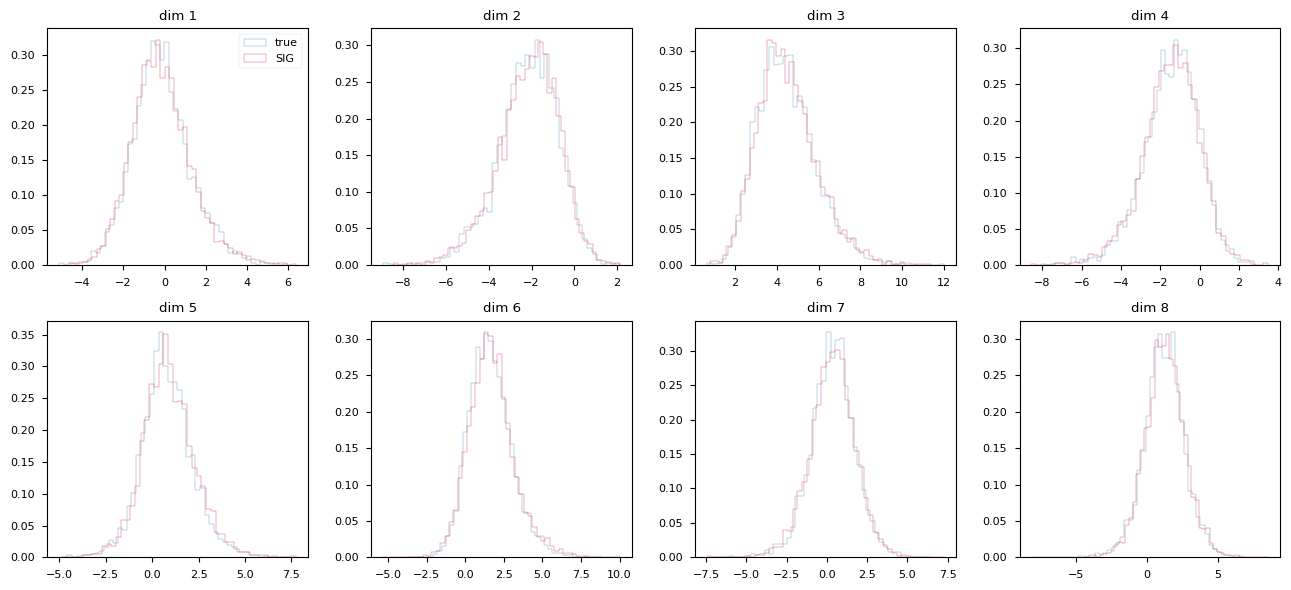

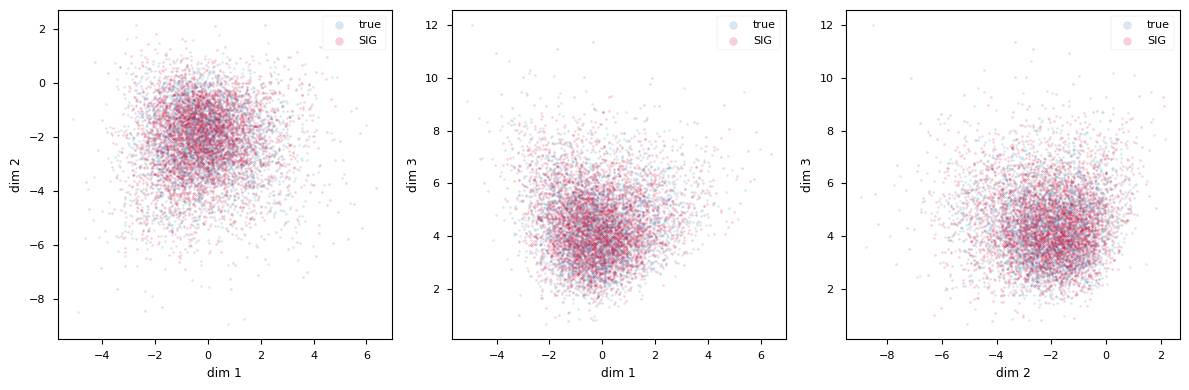

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for j, ax in enumerate(axes.ravel()):
    ax.hist(X8_true[:, j], bins=50, density=True, histtype="step", color="steelblue", label="true")
    ax.hist(X8_gen[:, j], bins=50, density=True, histtype="step", color="crimson", label="SIG")
    ax.set_title(f"dim {j + 1}")
    if j == 0:
        ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(X8_true[:, i], X8_true[:, j], s=2, alpha=0.2, color="steelblue", label="true")
    ax.scatter(X8_gen[:, i], X8_gen[:, j], s=2, alpha=0.2, color="crimson", label="SIG")
    ax.set_xlabel(f"dim {i + 1}")
    ax.set_ylabel(f"dim {j + 1}")
    ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

In [8]:
ks_pvals = np.array(
    [stats.ks_2samp(X8_true[:, j], X8_gen[:, j]).pvalue for j in range(8)]
)
print("per-dim KS p-values (gen vs true):", np.array2string(ks_pvals, precision=3))
print(f"MMD² gen vs true:  {mmd_rbf(X8_gen, X8_true):.5f}")
print(f"MMD² true vs true: {mmd_rbf(make_rotated_skew(4_000, seed=3), X8_true):.5f}")
print(f"SWD  gen vs true:  {swd(X8_gen, X8_true):.4f}")
print(f"SWD  true vs true: {swd(make_rotated_skew(4_000, seed=3), X8_true):.4f}")

per-dim KS p-values (gen vs true): [0.741 0.3   0.108 0.573 0.001 0.069 0.416 0.121]


MMD² gen vs true:  0.00052


MMD² true vs true: 0.00007
SWD  gen vs true:  0.0664
SWD  true vs true: 0.0455


---
## Summary

- `SIG.sample()` produces samples visually indistinguishable from true
  draws on multi-modal and curved 2D targets.
- Quantitatively, generated-vs-true MMD and SWD sit within a small factor
  of the true-vs-true noise floor, and per-dimension KS tests accept the
  generated marginals for nearly all dimensions in 8D (with several
  thousand samples, KS is sensitive enough to flag even tiny residual
  marginal mismatches).
- `sample(n)` is just `inverse_transform` applied to Gaussian noise — the
  flow's exact invertibility is what makes generation cheap and exact.

## See Also

- [Theory — RBIG vs SIG/GIS](../notes/sliced_iterative_gaussianization.md)
- [GIS Demo](14_sliced_gaussianization.ipynb)
- [Density Estimation Quality](16_gis_density_estimation.ipynb)